# Kaggle Vision-to-Voice Studio
## `kaggle-vllm` + Qwen2.5-VL + ElevenLabs Text-to-Speech + Sound Effects

**Goal:** turn an image into a short narrated audio scene using a Hugging Face multimodal model running through your `kaggle-vllm` runtime on Kaggle's **2 × NVIDIA Tesla T4** GPUs, then send the generated narration and sound-design prompt to your **ElevenLabs account** through the official Python SDK.

### Pipeline

`Image → Qwen2.5-VL-3B-Instruct (vLLM / dual T4) → structured narration + SFX prompt → ElevenLabs TTS + Sound Effects`

This resembles an **ElevenCreative** workflow: visual understanding happens locally in Kaggle, while ElevenLabs turns the generated creative direction into production audio.

### Why this is useful for an ElevenLabs inference-engineering portfolio

- exercises **multimodal vLLM serving** rather than text-only inference;
- uses real **TP=2 / NCCL** through `kaggle-vllm`;
- keeps the model-to-serving path reproducible and constrained to the validated T4 profile;
- sends model output to a real downstream production API;
- measures both the local multimodal inference stage and the remote TTS stage;
- verifies that the TTS generation is visible in the authenticated ElevenLabs account history.

> **Important:** this notebook is designed from the `kaggle-vllm==0.2.0` acceptance/bootstrap pattern. `kaggle-vllm` validates the runtime, but Qwen2.5-VL itself is an additional multimodal workload and should be treated as a new compatibility experiment until you execute and preserve evidence on Kaggle.

## Before running

1. Create a **fresh Kaggle notebook**.
2. Enable **Internet**.
3. Select accelerator **GPU T4 ×2**.
4. Add these Kaggle Secrets:
   - `ELEVENLABS_API_KEY` — required.
   - `HF_TOKEN` — optional for public Hugging Face downloads, useful for rate limits.
   - `ELEVENLABS_VOICE_ID` — optional. If omitted, the notebook uses the official ElevenLabs example voice ID.
5. Run cells in order.

The notebook never prints secret values.

In [1]:
# 1. Validate the Kaggle environment
from pathlib import Path
import gc
import hashlib
import json
import os
import platform
import re
import shutil
import subprocess
import sys
import time

import torch

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("Torch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
subprocess.run(["nvidia-smi", "-L"], check=False)
subprocess.run(["nvidia-smi", "topo", "-m"], check=False)

assert os.path.exists("/kaggle"), "This notebook is intended for Kaggle."
assert torch.cuda.is_available(), "Enable a GPU accelerator."
assert torch.cuda.device_count() == 2, "Select Kaggle's T4 x2 accelerator."
for idx in range(2):
    name = torch.cuda.get_device_name(idx)
    print(f"GPU {idx}: {name}")
    assert "T4" in name, f"Expected Tesla T4, got {name}"

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
Torch CUDA: 12.8
CUDA available: True
GPU count: 2
GPU 0: Tesla T4 (UUID: GPU-7912358c-4c20-a25a-90d2-6e906ceb5f06)
GPU 1: Tesla T4 (UUID: GPU-58589aac-8634-64d3-baca-983df2b1034f)
	GPU0	GPU1	CPU Affinity	NUMA Affinity	GPU NUMA ID
GPU0	 X 	PHB	0-3	0		N/A
GPU1	PHB	 X 	0-3	0		N/A

Legend:

  X    = Self
  SYS  = Connection traversing PCIe as well as the SMP interconnect between NUMA nodes (e.g., QPI/UPI)
  NODE = Connection traversing PCIe as well as the interconnect between PCIe Host Bridges within a NUMA node
  PHB  = Connection traversing PCIe as well as a PCIe Host Bridge (typically the CPU)
  PXB  = Connection traversing multiple PCIe bridges (without traversing the PCIe Host Bridge)
  PIX  = Connection traversing at most a single PCIe bridge
  NV#  = Connection traversing a bonded set of # NVLinks
GPU 0: Tesla T4
GPU 1: Tesla T4


In [2]:
# 2. Load secrets without printing them
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()

def get_secret(name, required=False):
    try:
        value = secrets.get_secret(name)
    except Exception:
        value = None
    if required and not value:
        raise RuntimeError(f"Missing required Kaggle Secret: {name}")
    return value

ELEVENLABS_API_KEY = get_secret("ELEVENLABS_API_KEY", required=True)
HF_TOKEN = get_secret("HF_TOKEN", required=False)
ELEVENLABS_VOICE_ID = get_secret("ELEVENLABS_VOICE_ID", required=False)

os.environ["ELEVENLABS_API_KEY"] = ELEVENLABS_API_KEY
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN

print("ELEVENLABS_API_KEY: loaded")
print("HF_TOKEN:", "loaded" if HF_TOKEN else "not set (public download will be used)")
print("ELEVENLABS_VOICE_ID:", "loaded" if ELEVENLABS_VOICE_ID else "not set; using default")

ELEVENLABS_API_KEY: loaded
HF_TOKEN: loaded
ELEVENLABS_VOICE_ID: not set; using default


## Install only the lightweight SDKs

`kaggle-vllm` deliberately does **not** replace Kaggle's system PyTorch/CUDA stack. Its native vLLM runtime is staged separately in the next step.

In [3]:
# 3. Install the public kaggle-vllm SDK and ElevenLabs Python SDK
subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "--no-cache-dir", "--upgrade",
        "kaggle-vllm[hub]==0.2.0",
        "elevenlabs",
        "pillow",
        "requests",
    ],
    check=True,
)

import kaggle_vllm
import elevenlabs

print("kaggle-vllm:", kaggle_vllm.__version__)
print("elevenlabs module:", elevenlabs.__file__)
assert kaggle_vllm.__version__ == "0.2.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 243.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 326.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
kaggle-vllm: 0.2.0
elevenlabs module: /usr/local/lib/python3.12/dist-packages/elevenlabs/__init__.py


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.3.0 which is incompatible.


## Bootstrap the validated vLLM CUDA runtime

This follows the same clean, notebook-owned staging pattern used by your `kaggle-vllm` acceptance notebooks. It downloads and verifies the immutable native runtime instead of altering Kaggle's preinstalled Torch/CUDA environment.

In [4]:
# 4. Strict bootstrap into notebook-owned paths
RUNTIME_ROOT = Path("/kaggle/working/vision-to-voice-runtime")
STAGED = RUNTIME_ROOT / "vllm-staged"
OVERLAY = RUNTIME_ROOT / "vllm-runtime-overlay"
CACHE = RUNTIME_ROOT / "cache"
MANIFEST = RUNTIME_ROOT / "kaggle-vllm-runtime.json"

if RUNTIME_ROOT.exists():
    print("Removing previous notebook-owned runtime:", RUNTIME_ROOT)
    shutil.rmtree(RUNTIME_ROOT)
RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)

bootstrap_cmd = [
    "kaggle-vllm", "bootstrap", "--strict",
    "--staged", str(STAGED),
    "--overlay", str(OVERLAY),
    "--cache", str(CACHE),
    "--manifest", str(MANIFEST),
]

subprocess.run(["kaggle-vllm", "fingerprint"], check=True)
subprocess.run(bootstrap_cmd + ["--dry-run"], check=True)
subprocess.run(bootstrap_cmd, check=True)
assert MANIFEST.is_file()
print("Runtime manifest:", MANIFEST)

{
  "is_kaggle": true,
  "python": "3.12.13",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "torch": "2.10.0+cu128",
  "torch_path": "/usr/local/lib/python3.12/dist-packages/torch/__init__.py",
  "torch_cuda": "12.8",
  "cuda_available": true,
  "gpus": [
    {
      "index": 0,
      "name": "Tesla T4",
      "capability": [
        7,
        5
      ],
      "total_memory": 15636037632
    },
    {
      "index": 1,
      "name": "Tesla T4",
      "capability": [
        7,
        5
      ],
      "total_memory": 15636037632
    }
  ],
  "nccl": "2.27.5",
  "nvcc": "/usr/local/cuda/bin/nvcc",
  "nvcc_version": "nvcc: NVIDIA (R) Cuda compiler driver\nCopyright (c) 2005-2025 NVIDIA Corporation\nBuilt on Fri_Feb_21_20:23:50_PST_2025\nCuda compilation tools, release 12.8, V12.8.93\nBuild cuda_12.8.r12.8/compiler.35583870_0",
  "cuda_home": "/usr/local/cuda",
  "cuda_driver": "/usr/local/nvidia/lib64/libcuda.so",
  "cmake_library_path": null,
  "driver_version": "580.159.04",


In [5]:
# 5. Activate staged vLLM and verify the native path
os.environ["KAGGLE_VLLM_MANIFEST"] = str(MANIFEST)

from kaggle_vllm import activate_runtime
assert activate_runtime(MANIFEST)

import importlib
import vllm

print("vLLM version:", getattr(vllm, "__version__", "unknown"))
print("vLLM path:", vllm.__file__)
for module_name in ("vllm._C", "vllm._moe_C", "vllm.cumem_allocator"):
    module = importlib.import_module(module_name)
    print(module_name, "->", module.__file__)

print("Torch still:", torch.__version__, torch.version.cuda, torch.__file__)

vLLM version: 0.18.2.dev0+ga26e8dc7f.d20260822
vLLM path: /kaggle/working/vision-to-voice-runtime/vllm-staged/vllm/__init__.py
vllm._C -> /kaggle/working/vision-to-voice-runtime/vllm-staged/vllm/_C.abi3.so
vllm._moe_C -> /kaggle/working/vision-to-voice-runtime/vllm-staged/vllm/_moe_C.abi3.so
vllm.cumem_allocator -> /kaggle/working/vision-to-voice-runtime/vllm-staged/vllm/cumem_allocator.abi3.so
Torch still: 2.10.0+cu128 12.8 /usr/local/lib/python3.12/dist-packages/torch/__init__.py


## Choose the multimodal Hugging Face model

This project uses **`Qwen/Qwen2.5-VL-3B-Instruct`** because it is an image-text-to-text vision-language model and is small enough to be a reasonable dual-T4 experiment. We cap context length and concurrent sequences to reduce memory pressure.

The notebook intentionally uses the standard FP16 model rather than assuming an AWQ kernel path is compatible with the validated SM75 runtime.

In [6]:
# 6. Configuration
MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
TENSOR_PARALLEL_SIZE = 2
MAX_MODEL_LEN = 2048
GPU_MEMORY_UTILIZATION = 0.82

# You can replace this URL with a direct image URL or set USER_IMAGE_PATH below.
DEFAULT_IMAGE_URL = "https://vllm-public-assets.s3.us-west-2.amazonaws.com/multimodal_asset/duck.jpg"
USER_IMAGE_PATH = None  # e.g. "/kaggle/input/my-images/product.jpg"

OUTPUT_ROOT = Path("/kaggle/working/vision-to-voice-output")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "model": MODEL_ID,
    "tp": TENSOR_PARALLEL_SIZE,
    "max_model_len": MAX_MODEL_LEN,
    "gpu_memory_utilization": GPU_MEMORY_UTILIZATION,
}, indent=2))

{
  "model": "Qwen/Qwen2.5-VL-3B-Instruct",
  "tp": 2,
  "max_model_len": 2048,
  "gpu_memory_utilization": 0.82
}


Image source: https://vllm-public-assets.s3.us-west-2.amazonaws.com/multimodal_asset/duck.jpg
Image size: (1024, 647)


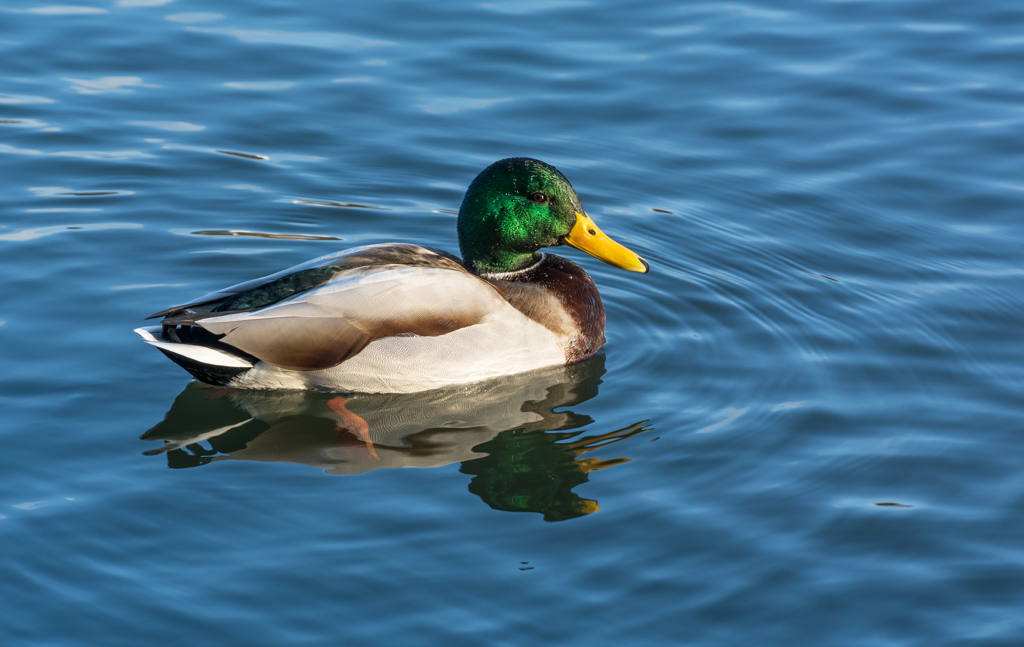

In [7]:
# 7. Load the image
from io import BytesIO
from PIL import Image
import requests
from IPython.display import display

if USER_IMAGE_PATH:
    IMAGE_SOURCE = USER_IMAGE_PATH
    image = Image.open(USER_IMAGE_PATH).convert("RGB")
else:
    IMAGE_SOURCE = DEFAULT_IMAGE_URL
    response = requests.get(DEFAULT_IMAGE_URL, timeout=60)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")

# Keep visual processing bounded for the T4 experiment.
image.thumbnail((1024, 1024))
print("Image source:", IMAGE_SOURCE)
print("Image size:", image.size)
display(image)

## Run multimodal inference through `kaggle-vllm`

The VLM produces a **machine-readable creative brief** with two fields:

- `narration`: speech that will be sent to ElevenLabs Text-to-Speech.
- `sound_effect_prompt`: an optional environmental sound prompt that will be sent to ElevenLabs Sound Effects.

The prompt asks the model not to invent identities, brands, locations, or events that are not visually supported.

In [8]:
# 8. Instantiate Qwen2.5-VL through KaggleLLM (upstream vLLM underneath)

import importlib
import os
from pathlib import Path
import subprocess
import sys
import time

# OVERLAY was created by the earlier kaggle-vllm bootstrap cell.
assert OVERLAY.exists(), f"kaggle-vllm overlay does not exist: {OVERLAY}"

print("Repairing Pillow inside runtime overlay:", OVERLAY)

# Install one complete Pillow distribution into the notebook-owned overlay.
# This avoids modifying/replacing Kaggle's PyTorch/CUDA installation.
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-cache-dir",
        "--upgrade",
        "--force-reinstall",
        "--target",
        str(OVERLAY),
        "Pillow",
    ],
    check=True,
)

# Ensure the kaggle-vllm overlay has priority for Python dependencies.
overlay_str = str(OVERLAY)
while overlay_str in sys.path:
    sys.path.remove(overlay_str)
sys.path.insert(0, overlay_str)

# Remove stale Pillow / torchvision modules that may have been imported before
# the Pillow upgrade. Also remove the vLLM modules whose import previously failed.
purge_prefixes = (
    "PIL",
    "torchvision",
)

purge_exact = {
    "vllm.sampling_params",
    "vllm.config",
    "vllm.config.model",
    "vllm.transformers_utils.config",
}

for module_name in list(sys.modules):
    if (
        module_name in purge_exact
        or any(
            module_name == prefix or module_name.startswith(prefix + ".")
            for prefix in purge_prefixes
        )
    ):
        sys.modules.pop(module_name, None)

importlib.invalidate_caches()

# Verify that Pillow is now one internally consistent installation.
import PIL
import PIL._typing
from PIL import Image

print("Pillow version:", PIL.__version__)
print("Pillow path:", PIL.__file__)
print("PIL._typing path:", PIL._typing.__file__)

assert hasattr(
    PIL._typing, "_Ink"
), (
    "Pillow is still inconsistent: PIL._typing._Ink is missing. "
    "Restart the Kaggle session and rerun the notebook from the beginning."
)

# Recreate the image using the repaired Pillow module because the previous
# `image` object was constructed with the old Pillow module.
from io import BytesIO
import requests

if USER_IMAGE_PATH:
    IMAGE_SOURCE = USER_IMAGE_PATH
    image = Image.open(USER_IMAGE_PATH).convert("RGB")
else:
    IMAGE_SOURCE = DEFAULT_IMAGE_URL
    response = requests.get(DEFAULT_IMAGE_URL, timeout=60)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")

image.thumbnail((1024, 1024))

# The actual inference imports should now use the consistent Pillow runtime.
from kaggle_vllm import KaggleLLM
from vllm import SamplingParams

print("vLLM SamplingParams import: OK")
print("Image:", IMAGE_SOURCE, image.size)

start_load = time.perf_counter()

llm = KaggleLLM(
    model=MODEL_ID,
    tensor_parallel_size=TENSOR_PARALLEL_SIZE,
    max_model_len=MAX_MODEL_LEN,
    gpu_memory_utilization=GPU_MEMORY_UTILIZATION,
    max_num_seqs=1,
    limit_mm_per_prompt={"image": 1},

    # Conservative settings for the validated Kaggle T4 / SM75 profile.
    dtype="float16",
    enforce_eager=True,
    disable_custom_all_reduce=True,
)

load_seconds = time.perf_counter() - start_load
print(f"Qwen2.5-VL initialized in {load_seconds:.2f}s")

Repairing Pillow inside runtime overlay: /kaggle/working/vision-to-voice-runtime/vllm-runtime-overlay
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 78.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.18.2.dev0+ga26e8dc7f.d20260822.cu128 requires flashinfer-python==0.6.6, which is not installed.
vllm 0.18.2.dev0+ga26e8dc7f.d20260822.cu128 requires nvidia-cudnn-frontend<1.19.0,>=1.13.0, which is not installed.
vllm 0.18.2.dev0+ga26e8dc7f.d20260822.cu128 requires nvidia-cutlass-dsl>=4.4.0.dev1, which is not installed.
vllm 0.18.2.dev0+ga26e8dc7f.d20260822.cu128 requires quack-kernels>=0.2.7, which is not installed.
vllm 0.18.2.dev0+ga26e8dc7f.d20260822.cu128 requires setuptools<81.0.0,>=77.0.3; python_version > "3.11", but you have setuptools 81.0.0 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.3.0 which is incompatible.
gradio 5.50.0 requires starlette<1.0,>=0.40.0, but you have

Pillow version: 12.3.0
Pillow path: /kaggle/working/vision-to-voice-runtime/vllm-runtime-overlay/PIL/__init__.py
PIL._typing path: /kaggle/working/vision-to-voice-runtime/vllm-runtime-overlay/PIL/_typing.py
vLLM SamplingParams import: OK
Image: https://vllm-public-assets.s3.us-west-2.amazonaws.com/multimodal_asset/duck.jpg (1024, 647)
INFO 09-03 06:56:55 [utils.py:233] non-default args: {'dtype': 'float16', 'max_model_len': 2048, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.82, 'max_num_seqs': 1, 'disable_log_stats': True, 'enforce_eager': True, 'disable_custom_all_reduce': True, 'limit_mm_per_prompt': {'image': 1}, 'model': 'Qwen/Qwen2.5-VL-3B-Instruct'}


config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

...

(Worker_TP0 pid=282) INFO 09-03 06:58:08 [gpu_model_runner.py:4481] Starting to load model Qwen/Qwen2.5-VL-3B-Instruct...
(Worker_TP1 pid=283) ERROR 09-03 06:58:08 [fa_utils.py:145] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
(Worker_TP1 pid=283) INFO 09-03 06:58:08 [mm_encoder_attention.py:230] Using AttentionBackendEnum.TORCH_SDPA for MMEncoderAttention.
(Worker_TP0 pid=282) ERROR 09-03 06:58:08 [fa_utils.py:145] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
(Worker_TP0 pid=282) INFO 09-03 06:58:08 [mm_encoder_attention.py:230] Using AttentionBackendEnum.TORCH_SDPA for MMEncoderAttention.
(Worker_TP1 pid=283) INFO 09-03 06:58:08 [vllm.py:775] Asynchronous scheduling is enabled.
(Worker_TP1 pid=283) WARNING 09-03 06:58:08 [vllm.py:809] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=n

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  50% Completed | 1/2 [00:01<00:01,  1.96s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:03<00:00,  1.71s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:03<00:00,  1.74s/it]
(Worker_TP0 pid=282) 


(Worker_TP0 pid=282) INFO 09-03 06:58:49 [default_loader.py:384] Loading weights took 3.55 seconds
(Worker_TP0 pid=282) INFO 09-03 06:58:50 [gpu_model_runner.py:4566] Model loading took 3.67 GiB memory and 41.121079 seconds
(Worker_TP1 pid=283) INFO 09-03 06:58:52 [gpu_model_runner.py:5488] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 video items of the maximum feature size.
(Worker_TP0 pid=282) INFO 09-03 06:58:52 [gpu_model_runner.py:5488] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 video items of the maximum feature size.
(Worker_TP0 pid=282) INFO 09-03 06:59:12 [gpu_worker.py:456] Available KV cache memory: 6.82 GiB
(EngineCore pid=258) INFO 09-03 06:59:12 [kv_cache_utils.py:1316] GPU KV cache size: 397,152 tokens
(EngineCore pid=258) INFO 09-03 06:59:12 [kv_cache_utils.py:1321] Maximum concurrency for 2,048 tokens per request: 193.92x
(EngineCore pid=258) INFO 09-03 06:59:13 [core.py:281] init engine 

(EngineCore pid=258) The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


(EngineCore pid=258) INFO 09-03 06:59:22 [vllm.py:775] Asynchronous scheduling is enabled.
(EngineCore pid=258) WARNING 09-03 06:59:22 [vllm.py:809] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
(EngineCore pid=258) WARNING 09-03 06:59:22 [vllm.py:820] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
(EngineCore pid=258) INFO 09-03 06:59:22 [vllm.py:985] Cudagraph is disabled under eager mode
(EngineCore pid=258) INFO 09-03 06:59:22 [compilation.py:289] Enabled custom fusions: norm_quant, act_quant
INFO 09-03 06:59:22 [llm.py:391] Supported tasks: ['generate']
Qwen2.5-VL initialized in 150.31s


In [9]:
# 9. Vision -> creative narration + sound-design prompt
instruction = """
You are creating a short, accessible audio scene from one image.
Return ONLY valid JSON with exactly these keys:
{
  "title": "short title",
  "narration": "50-90 word spoken narration grounded in visible details",
  "sound_effect_prompt": "one concise ambient sound-effect prompt",
  "visual_summary": "one sentence describing the image"
}

Rules:
- Describe only details reasonably supported by the image.
- Do not identify an unknown person, exact location, brand, or event unless visibly explicit.
- Make narration natural when spoken aloud.
- Keep the sound effect atmospheric rather than musical.
""".strip()

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image_pil", "image_pil": image},
            {"type": "text", "text": instruction},
        ],
    }
]

sampling = SamplingParams(
    temperature=0.2,
    top_p=0.9,
    max_tokens=260,
)

infer_start = time.perf_counter()
outputs = llm.chat(conversation, sampling_params=sampling)
vlm_seconds = time.perf_counter() - infer_start
raw_text = outputs[0].outputs[0].text.strip()

print(f"VLM inference: {vlm_seconds:.3f}s")
print(raw_text)

Rendering conversations:   0%|          | 0/1 [00:00<?, ?it/s]

INFO 09-03 07:01:26 [hf.py:320] Detected the chat template content format to be 'openai'. You can set `--chat-template-content-format` to override this.


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

VLM inference: 23.202s
{
  "title": "Duck on Calm Waters",
  "narration": "A male mallard duck floats gracefully on a serene body of water, its vibrant green head and yellow beak standing out against the blue backdrop. The duck's reflection dances on the water's surface, creating a mirror-like effect that enhances the tranquil scene.",
  "sound_effect_prompt": "Soft rustling of leaves",
  "visual_summary": "A male mallard duck is swimming calmly on a blue, rippling water surface, with its reflection visible below."
}


In [10]:
# 10. Parse and validate the model's JSON

def extract_json_object(text: str) -> dict:
    text = text.strip()
    # Remove a fenced-code wrapper if the model emits one despite the prompt.
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.I)
    text = re.sub(r"\s*```$", "", text)
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.S)
        if not match:
            raise
        return json.loads(match.group(0))

creative = extract_json_object(raw_text)
required = {"title", "narration", "sound_effect_prompt", "visual_summary"}
missing = required - creative.keys()
assert not missing, f"Missing fields: {sorted(missing)}"
assert 20 <= len(creative["narration"]) <= 1500

CREATIVE_JSON = OUTPUT_ROOT / "creative_brief.json"
CREATIVE_JSON.write_text(json.dumps(creative, indent=2, ensure_ascii=False), encoding="utf-8")

print(json.dumps(creative, indent=2, ensure_ascii=False))
print("Saved:", CREATIVE_JSON)

{
  "title": "Duck on Calm Waters",
  "narration": "A male mallard duck floats gracefully on a serene body of water, its vibrant green head and yellow beak standing out against the blue backdrop. The duck's reflection dances on the water's surface, creating a mirror-like effect that enhances the tranquil scene.",
  "sound_effect_prompt": "Soft rustling of leaves",
  "visual_summary": "A male mallard duck is swimming calmly on a blue, rippling water surface, with its reflection visible below."
}
Saved: /kaggle/working/vision-to-voice-output/creative_brief.json


## Send Kaggle-generated AI data to ElevenLabs

The **narration text was created on Kaggle** by the multimodal model. The next call sends that text to your authenticated ElevenLabs workspace and creates a Text-to-Speech generation.

By default, ElevenLabs TTS API requests are logged to generation history. The notebook records the returned request ID and then queries account history using the official Python SDK to verify that the generation is present.

In [11]:
# 11. Connect to your ElevenLabs account and select a voice
from elevenlabs import ElevenLabs

client = ElevenLabs(api_key=ELEVENLABS_API_KEY)

DEFAULT_VOICE_ID = "JBFqnCBsd6RMkjVDRZzb"  # official SDK README example voice
voice_id = ELEVENLABS_VOICE_ID or DEFAULT_VOICE_ID

# Prove that the account/API key works and show a small voice inventory.
voices_response = client.voices.get_all(show_legacy=False)
voices = list(voices_response.voices)
print(f"Accessible voices: {len(voices)}")
for v in voices[:8]:
    print(" -", v.name, v.voice_id)

print("Selected voice_id:", voice_id)

Accessible voices: 21
 - Roger - Laid-Back, Casual, Resonant CwhRBWXzGAHq8TQ4Fs17
 - Sarah - Mature, Reassuring, Confident EXAVITQu4vr4xnSDxMaL
 - Laura - Enthusiast, Quirky Attitude FGY2WhTYpPnrIDTdsKH5
 - Charlie - Deep, Confident, Energetic IKne3meq5aSn9XLyUdCD
 - George - Warm, Captivating Storyteller JBFqnCBsd6RMkjVDRZzb
 - Callum - Husky Trickster N2lVS1w4EtoT3dr4eOWO
 - River - Relaxed, Neutral, Informative SAz9YHcvj6GT2YYXdXww
 - Harry - Fierce Warrior SOYHLrjzK2X1ezoPC6cr
Selected voice_id: JBFqnCBsd6RMkjVDRZzb


In [13]:
# 12. Generate ElevenLabs speech from the Kaggle-produced narration

import time

TTS_MODEL_ID = "eleven_multilingual_v2"
TTS_OUTPUT = OUTPUT_ROOT / "elevenlabs_narration.mp3"

narration = creative["narration"].strip()

assert narration, "Narration is empty."

print("Narration:")
print(narration)
print()

tts_start = time.perf_counter()

# ElevenLabs' raw TTS API returns a context manager.
# Inside the context, raw_response is an HttpResponse whose .data
# is an iterator yielding audio bytes.
with client.text_to_speech.with_raw_response.convert(
    text=narration,
    voice_id=voice_id,
    model_id=TTS_MODEL_ID,
    output_format="mp3_44100_128",
) as raw_response:

    # Consume the streaming byte iterator while the HTTP response is open.
    audio_bytes = b"".join(raw_response.data)

    # Capture response metadata before leaving the context manager.
    headers = raw_response.headers

    request_id = headers.get("request-id")
    trace_id = headers.get("x-trace-id")

    # Header names can vary in capitalization / availability,
    # so check both likely forms.
    character_cost = (
        headers.get("character-cost")
        or headers.get("x-character-count")
        or headers.get("x-character-cost")
    )

# Save the generated speech to Kaggle output.
TTS_OUTPUT.write_bytes(audio_bytes)

tts_seconds = time.perf_counter() - tts_start

print(f"Saved TTS: {TTS_OUTPUT}")
print(f"Audio size: {len(audio_bytes):,} bytes")
print(f"ElevenLabs TTS wall time: {tts_seconds:.3f}s")
print("request-id:", request_id)
print("x-trace-id:", trace_id)
print("character-cost:", character_cost)

assert len(audio_bytes) > 0, "ElevenLabs returned an empty audio payload."

print("\nElevenLabs TTS generation: OK")

Narration:
A male mallard duck floats gracefully on a serene body of water, its vibrant green head and yellow beak standing out against the blue backdrop. The duck's reflection dances on the water's surface, creating a mirror-like effect that enhances the tranquil scene.

Saved TTS: /kaggle/working/vision-to-voice-output/elevenlabs_narration.mp3
Audio size: 265,030 bytes
ElevenLabs TTS wall time: 2.559s
request-id: vANoIwcYBCRMzb37Iqzo
x-trace-id: 3b904d9c0aee2ff6f83617b126074bb2
character-cost: 260

ElevenLabs TTS generation: OK


In [14]:
# 13. Verify that the TTS generation reached your ElevenLabs account history
# The SDK's history endpoint returns TTS history. We match the API request-id when available.
time.sleep(1.0)
history_response = client.history.list(page_size=30, source="TTS")
history = list(history_response.history)

matched = None
if request_id:
    matched = next((item for item in history if getattr(item, "request_id", None) == request_id), None)
if matched is None:
    # Fallback to matching recent text/voice if request headers were unavailable.
    matched = next(
        (
            item for item in history
            if getattr(item, "text", None) == narration
            and getattr(item, "voice_id", None) == voice_id
        ),
        None,
    )

if matched:
    print("ACCOUNT HISTORY VERIFIED")
    print("history_item_id:", matched.history_item_id)
    print("voice:", getattr(matched, "voice_name", None), matched.voice_id)
    print("model:", matched.model_id)
    print("source:", matched.source)
else:
    print("TTS API call succeeded, but the item was not found in the first history page yet.")
    print("Re-run this verification cell after a few seconds.")

ACCOUNT HISTORY VERIFIED
history_item_id: mhKf2NAjia8d13pQLTqj
voice: George - Warm, Captivating Storyteller JBFqnCBsd6RMkjVDRZzb
model: eleven_multilingual_v2
source: TTS


## Optional second ElevenLabs feature: Sound Effects

The VLM also generated a sound-design prompt. We can send it to ElevenLabs **Sound Effects** to create an ambient layer for the scene.

Current ElevenLabs history APIs list speech generations but **do not include Music or SFX generations**, so this cell saves the SFX response in Kaggle and records its prompt in the evidence manifest; it does not claim SFX history verification.

In [15]:
# 14. Generate an ambient sound effect with ElevenLabs
SFX_OUTPUT = OUTPUT_ROOT / "elevenlabs_ambient_sfx.mp3"
sfx_prompt = creative["sound_effect_prompt"].strip()

sfx_start = time.perf_counter()
sfx_stream = client.text_to_sound_effects.convert(
    text=sfx_prompt,
    duration_seconds=5.0,
    prompt_influence=0.5,
    loop=False,
    output_format="mp3_44100_128",
)
sfx_bytes = b"".join(sfx_stream)
SFX_OUTPUT.write_bytes(sfx_bytes)
sfx_seconds = time.perf_counter() - sfx_start

print("SFX prompt:", sfx_prompt)
print(f"Saved SFX: {SFX_OUTPUT} ({len(sfx_bytes):,} bytes)")
print(f"ElevenLabs SFX wall time: {sfx_seconds:.3f}s")

SFX prompt: Soft rustling of leaves
Saved SFX: /kaggle/working/vision-to-voice-output/elevenlabs_ambient_sfx.mp3 (81,128 bytes)
ElevenLabs SFX wall time: 1.759s


In [16]:
# 15. Listen inside Kaggle
from IPython.display import Audio, display

print("Narration")
display(Audio(filename=str(TTS_OUTPUT)))
print("Ambient sound effect")
display(Audio(filename=str(SFX_OUTPUT)))

Narration


Ambient sound effect


## Preserve a reproducible evidence bundle

This captures enough information to discuss the project in an interview without claiming performance that was not measured. It records hardware/software identity, local multimodal inference time, ElevenLabs request metadata, generated prompts, and SHA256 hashes of produced files.

In [17]:
# 16. Evidence manifest + ZIP bundle

def sha256_file(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

history_item_id = getattr(matched, "history_item_id", None) if matched else None

evidence = {
    "project": "kaggle-vision-to-voice-elevenlabs",
    "created_unix": int(time.time()),
    "image_source": IMAGE_SOURCE,
    "multimodal_model": MODEL_ID,
    "kaggle_vllm_version": kaggle_vllm.__version__,
    "vllm_version": getattr(vllm, "__version__", None),
    "torch_version": torch.__version__,
    "torch_cuda": torch.version.cuda,
    "gpus": [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())],
    "tensor_parallel_size": TENSOR_PARALLEL_SIZE,
    "max_model_len": MAX_MODEL_LEN,
    "gpu_memory_utilization": GPU_MEMORY_UTILIZATION,
    "model_load_seconds": load_seconds,
    "vlm_inference_seconds": vlm_seconds,
    "elevenlabs_tts_model": TTS_MODEL_ID,
    "elevenlabs_voice_id": voice_id,
    "elevenlabs_tts_seconds": tts_seconds,
    "elevenlabs_request_id": request_id,
    "elevenlabs_trace_id": trace_id,
    "elevenlabs_character_cost": character_cost,
    "elevenlabs_history_item_id": history_item_id,
    "elevenlabs_history_verified": bool(matched),
    "elevenlabs_sfx_seconds": sfx_seconds,
    "creative_brief": creative,
    "files": {
        "creative_brief.json": sha256_file(CREATIVE_JSON),
        "elevenlabs_narration.mp3": sha256_file(TTS_OUTPUT),
        "elevenlabs_ambient_sfx.mp3": sha256_file(SFX_OUTPUT),
    },
}

EVIDENCE_JSON = OUTPUT_ROOT / "evidence.json"
EVIDENCE_JSON.write_text(json.dumps(evidence, indent=2, ensure_ascii=False), encoding="utf-8")

ARCHIVE = Path("/kaggle/working/kaggle-vision-to-voice-elevenlabs.zip")
if ARCHIVE.exists():
    ARCHIVE.unlink()
shutil.make_archive(str(ARCHIVE.with_suffix("")), "zip", root_dir=OUTPUT_ROOT)

print(json.dumps(evidence, indent=2, ensure_ascii=False))
print("Evidence:", EVIDENCE_JSON)
print("Archive:", ARCHIVE)

{
  "project": "kaggle-vision-to-voice-elevenlabs",
  "created_unix": 1788419436,
  "image_source": "https://vllm-public-assets.s3.us-west-2.amazonaws.com/multimodal_asset/duck.jpg",
  "multimodal_model": "Qwen/Qwen2.5-VL-3B-Instruct",
  "kaggle_vllm_version": "0.2.0",
  "vllm_version": "0.18.2.dev0+ga26e8dc7f.d20260822",
  "torch_version": "2.10.0+cu128",
  "torch_cuda": "12.8",
  "gpus": [
    "Tesla T4",
    "Tesla T4"
  ],
  "tensor_parallel_size": 2,
  "max_model_len": 2048,
  "gpu_memory_utilization": 0.82,
  "model_load_seconds": 150.31044482699997,
  "vlm_inference_seconds": 23.202124276000063,
  "elevenlabs_tts_model": "eleven_multilingual_v2",
  "elevenlabs_voice_id": "JBFqnCBsd6RMkjVDRZzb",
  "elevenlabs_tts_seconds": 2.5591626570001154,
  "elevenlabs_request_id": "vANoIwcYBCRMzb37Iqzo",
  "elevenlabs_trace_id": "3b904d9c0aee2ff6f83617b126074bb2",
  "elevenlabs_character_cost": "260",
  "elevenlabs_history_item_id": "mhKf2NAjia8d13pQLTqj",
  "elevenlabs_history_verified": tr

## What this project demonstrates

**Local / Kaggle side**
- Hugging Face multimodal model: `Qwen/Qwen2.5-VL-3B-Instruct`.
- Upstream vLLM delivered through `kaggle-vllm`.
- Dual-T4 tensor parallel configuration.
- Image → structured creative data generation.
- Measurement and evidence capture.

**ElevenLabs side**
- Official Python SDK authentication using a Kaggle Secret.
- Kaggle-generated narration sent to **Text to Speech**.
- TTS output written back to Kaggle and generation verified in **ElevenLabs account history**.
- Kaggle-generated environmental prompt sent to **Sound Effects**.

### Recommended portfolio description

> Built a dual-T4 multimodal inference pipeline on Kaggle using my `kaggle-vllm` compatibility runtime and Qwen2.5-VL. The VLM converts an image into grounded narration and sound-design instructions; those outputs are sent through the official ElevenLabs Python SDK to generate spoken audio and environmental sound effects. The notebook records local inference timing, ElevenLabs request metadata, account-history verification, and checksummed evidence artifacts.

### Honest limitation

This is a **portfolio integration experiment**, not evidence that I optimized ElevenLabs' internal inference stack. The value is demonstrating multimodal serving, constrained-GPU deployment, API integration, measurement, and a concrete voice-AI workflow end to end.

In [19]:
# 17. Verify the Kaggle -> ElevenLabs transfer and save a portable manifest
#
# Studio API is not available on this ElevenLabs account.
# This cell verifies the successful TTS transfer through ElevenLabs History
# and saves the complete experiment metadata in Kaggle.

import json
import time
from pathlib import Path

TRANSFER_MANIFEST = OUTPUT_ROOT / "elevenlabs_transfer_manifest.json"

assert "client" in globals(), "ElevenLabs client is not available."
assert "creative" in globals(), "Creative brief is not available."

# ------------------------------------------------------------
# 1. Find the ElevenLabs TTS generation created by this notebook
# ------------------------------------------------------------

history_response = client.history.list(page_size=100)
history_items = list(history_response.history)

matched_item = None

# Best match: request ID returned from the TTS call
if globals().get("request_id"):
    for item in history_items:
        if getattr(item, "request_id", None) == request_id:
            matched_item = item
            break

# Fallback: match exact generated narration
if matched_item is None:
    target_text = creative["narration"].strip()

    for item in history_items:
        if (
            getattr(item, "source", None) == "TTS"
            and (getattr(item, "text", "") or "").strip() == target_text
        ):
            matched_item = item
            break

# ------------------------------------------------------------
# 2. Build portable experiment manifest
# ------------------------------------------------------------

manifest = {
    "project": "Kaggle Vision-to-Voice",
    "timestamp_utc": time.strftime(
        "%Y-%m-%dT%H:%M:%SZ",
        time.gmtime(),
    ),

    "kaggle": {
        "model": globals().get("MODEL_ID"),
        "runtime": "kaggle-vllm / upstream vLLM",
        "tensor_parallel_size": globals().get(
            "TENSOR_PARALLEL_SIZE"
        ),
        "hardware": "2 x NVIDIA Tesla T4",
        "image_source": str(
            globals().get("IMAGE_SOURCE", "unknown")
        ),
        "model_load_seconds": globals().get(
            "load_seconds"
        ),
        "vlm_inference_seconds": globals().get(
            "vlm_seconds"
        ),
    },

    "creative_output": {
        "title": creative.get("title"),
        "visual_summary": creative.get(
            "visual_summary"
        ),
        "narration": creative.get("narration"),
        "sound_effect_prompt": creative.get(
            "sound_effect_prompt"
        ),
    },

    "elevenlabs": {
        "tts_model": globals().get(
            "TTS_MODEL_ID"
        ),
        "voice_id": globals().get("voice_id"),
        "request_id": globals().get(
            "request_id"
        ),
        "trace_id": globals().get(
            "trace_id"
        ),
        "tts_seconds": globals().get(
            "tts_seconds"
        ),
        "history_verified": matched_item
        is not None,
        "history_item_id": (
            getattr(
                matched_item,
                "history_item_id",
                None,
            )
            if matched_item
            else None
        ),
        "history_source": (
            str(
                getattr(
                    matched_item,
                    "source",
                    None,
                )
            )
            if matched_item
            else None
        ),
    },

    "limitations": {
        "studio_api_transfer": False,
        "reason": (
            "ElevenLabs returned 403 invalid_subscription: "
            "Studio API requires explicit account whitelisting."
        ),
        "sound_effect_history_api": (
            "ElevenLabs History API does not include "
            "Music or SFX generations."
        ),
    },
}

# Preserve file hashes from the previous evidence file if available.
if (
    "EVIDENCE_JSON" in globals()
    and Path(EVIDENCE_JSON).exists()
):
    previous_evidence = json.loads(
        Path(EVIDENCE_JSON).read_text(
            encoding="utf-8"
        )
    )

    manifest["artifacts"] = previous_evidence.get(
        "files",
        {},
    )

TRANSFER_MANIFEST.write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

# ------------------------------------------------------------
# 3. Report verification
# ------------------------------------------------------------

print("=" * 70)
print("KAGGLE -> ELEVENLABS TRANSFER STATUS")
print("=" * 70)

if matched_item is not None:
    print("TTS generation: VERIFIED IN ELEVENLABS")
    print(
        "History item ID:",
        matched_item.history_item_id,
    )
    print(
        "Request ID:",
        getattr(
            matched_item,
            "request_id",
            None,
        ),
    )
    print(
        "Voice ID:",
        getattr(
            matched_item,
            "voice_id",
            None,
        ),
    )
    print(
        "Model ID:",
        getattr(
            matched_item,
            "model_id",
            None,
        ),
    )
else:
    print(
        "TTS generation was not matched in "
        "the first 100 history records."
    )

print()
print("Studio API: NOT AVAILABLE ON THIS ACCOUNT")
print(
    "Reason: explicit ElevenLabs whitelisting required."
)

print()
print(
    "Saved transfer manifest:",
    TRANSFER_MANIFEST,
)

KAGGLE -> ELEVENLABS TRANSFER STATUS
TTS generation: VERIFIED IN ELEVENLABS
History item ID: mhKf2NAjia8d13pQLTqj
Request ID: vANoIwcYBCRMzb37Iqzo
Voice ID: JBFqnCBsd6RMkjVDRZzb
Model ID: eleven_multilingual_v2

Studio API: NOT AVAILABLE ON THIS ACCOUNT
Reason: explicit ElevenLabs whitelisting required.

Saved transfer manifest: /kaggle/working/vision-to-voice-output/elevenlabs_transfer_manifest.json
